# Résolution d'équations différentielles multi-dimensionnelles
Ce notebook présente comment résoudre un système d'équations différentielles ordinaires (EDO) du premier ordre en utilisant **NumPy** pour la vectorialisation de l'équation différentielle.

En plusieurs dimensions, nous transformons souvent un problème d'ordre supérieur en un système de premier ordre :
$$\frac{d\mathbf{y}}{dt} = f(t, \mathbf{y})$$
où $\mathbf{y}$ est un vecteur d'état. En composantes, l'équation différentielle s'écrit

$$ \begin{pmatrix} y_1 '(t) \\ y_2 '(t) \\ \vdots \\ y_n '(t) \end{pmatrix} = \begin{pmatrix} f_1(t, \mathbf{y}) \\ f_2(t, \mathbf{y}) \\ \vdots \\ f_n(t, \mathbf{y}) \end{pmatrix}$$

La résolution numérique est identique à celle de l'équation différentielle en dimension 1. En effet, les méthodes numériques se "vectorialisent" naturellement. 

Par exemple, la relation du récurrence de l’algorithme RK4 est 
${\mathbf{y}_{i+1}}={\mathbf{y}_{i}}+\frac{h}{6}({\mathbf{k}_{1}}+2{\mathbf{k}_{2}}+2{\mathbf{k}_{3}}+{\mathbf{k}_{4}})$

avec

- ${\mathbf{k}_{1}}=f({{t}_{i}};{\mathbf{y}_{i}})$
- ${\mathbf{k}_{2}}=f\left( {{t}_{i}}+\frac{h}{2};{\mathbf{y}_{i}}+\frac{h}{2}{\mathbf{k}_{1}} \right)$
- ${\mathbf{k}_{3}}=f\left( {t_{i}}+\frac{h}{2};{\mathbf{y}_{i}}+\frac{h}{2}{\mathbf{k}_{2}} \right)$
- ${\mathbf{k}_{4}}=f\left( {{t}_{i}}+h,{\mathbf{y}_{i}}+h\cdot {\mathbf{k}_{3}} \right)$

où chaque terme en gras est un vecteur.

Pour l'implémentation en python, elle est identique, il suffit que $\mathbf{y}_0$ soit un vecteur en prenant par exemple un `numpy` `array`.

In [6]:
import numpy as np # pour utiliser des vecteurs (numpy array)
import matplotlib.pyplot as plt

In [10]:
def rk4(f,t0,y0,b,n):
    h=(b-t0)/n
    T, Y = [t0], [y0]
    for k in range(1,n+1):
        t1 = t0 + h
        k1 = h * f(t0,y0)
        k2 = h * f(t0+h/2, y0+k1/2)
        k3 = h * f(t0+h/2, y0+k2/2)
        k4 = h * f(t0+h, y0+k3)
        y1 = y0+(1/6)*(k1+2*k2+2*k3+k4)
        T = T + [t1]
        Y = Y + [y1]
        t0 = t1
        y0 = y1
    return T,Y

# Exemple 1: Un oscillateur

Nous allons simuler un système masse-ressort, défini par $x'' + \omega^2x = 0$. En posant $v = x'$, on obtient le système :
1. $\frac{dx}{dt} = v$
2. $\frac{dv}{dt} = -\omega^2 x$

Sous forme vectorielle, on peut écrire $\frac{d\mathbf{y}}{dt} = f(t, \mathbf{y})$ avec 
$\mathbf{y}= \begin{pmatrix} y_1 (t) \\ y_2 (t) \end{pmatrix}$ et $f(t, \mathbf{y}) = \begin{pmatrix} y_2 (t) \\ -\omega^2 y_1 (t) \end{pmatrix}$.

On a identifié $y_1=x$ et $y_2=v$.

In [28]:
#CONSTANTES du SYSTEME
OMEGA = 2.0 #pulsation propre de l'oscillateur

def f_systeme_harmonique(t, y):
    dy1dt = y[1]
    dy2dt = -OMEGA**2 * y[0]
    return np.array([dy1dt, dy2dt])

In [42]:
# Paramètres de la solution

I = (0, 10) # Intervalle de temps de la solution [t0, b]
y0 = np.array([1.0, 0.0])  # Position initiale = 1, Vitesse initiale = 0 en t_0

In [43]:
# Résolution avec  RK4 
t, y = rk4(f_systeme_harmonique, I[0],y0,I[1], 1000)
y1,y2= np.transpose(y) # les composantes du vecteur y

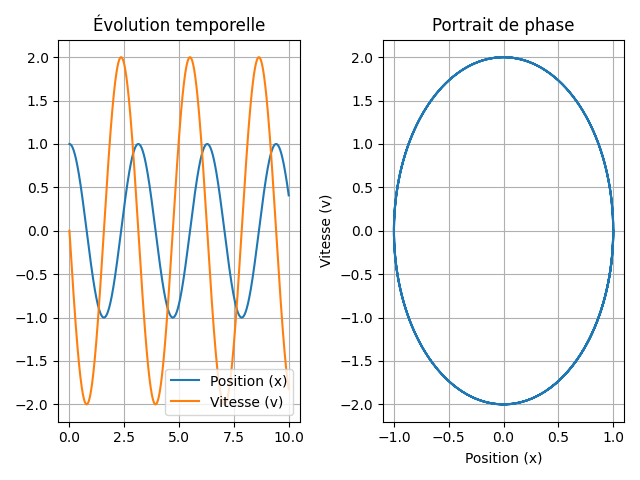

In [44]:
plt.figure()
plt.subplot(1, 2, 1)
plt.plot(t, y1, label='Position (x)')
plt.plot(t, y2, label='Vitesse (v)')
plt.title("Évolution temporelle")
plt.legend()
plt.grid(True)

# Portrait de phase (Espace des états)
plt.subplot(1, 2, 2)
plt.plot(y1, y2)
plt.xlabel('Position (x)')
plt.ylabel('Vitesse (v)')
plt.title("Portrait de phase")
plt.grid(True)

plt.tight_layout()
plt.show()

## Exemple 2 : Modèle Proie-Prédateur (Lotka-Volterra)
Ce modèle simule l'évolution de deux populations (par exemple, des lapins $L$ et des renards $R$).

$$\frac{dL}{dt} = \alpha L - \beta L\cdot R, \quad \frac{dR}{dt} = \delta L\cdot R - \gamma R$$

Sous forme vectorielle, on peut écrire $\frac{d\mathbf{y}}{dt} = f(t, \mathbf{y})$ avec 
$\mathbf{y}= \begin{pmatrix} y_1 (t) \\ y_2 (t) \end{pmatrix}$ et $f(t, \mathbf{y}) = \begin{pmatrix} \alpha y_1 (t) - \beta y_1 (t)\cdot y_2 (t) \\ \delta y_1 (t)\cdot y_2 (t) - \gamma y_2 (t) \end{pmatrix}$.

On a identifié $y_1=L$ et $y_2=R$.


In [45]:
#CONSTANTES du SYSTEME : taux de reproduction, prédation, etc.
alpha, beta, delta, gamma = (1.1, 0.4, 0.1, 0.4)

def lotka_volterra(t, y):
    y1 = y[0]
    y2 = y[1]
    dy1dt = alpha * y1 - beta * y1 * y2
    dy2dt = delta * y1 * y2 - gamma * y2
    return np.array([dy1dt, dy2dt])

In [46]:
# Paramètres de la solution

I = (0, 70) # Intervalle de temps de la solution entree le jour 1 et le jour 70
y0 = np.array([10, 5])  # 10 lapins, 5 renards

In [47]:
# Résolution avec  RK4 
t, y = rk4(lotka_volterra, I[0],y0,I[1], 1000)
y1,y2= np.transpose(y) # les composantes du vecteur y

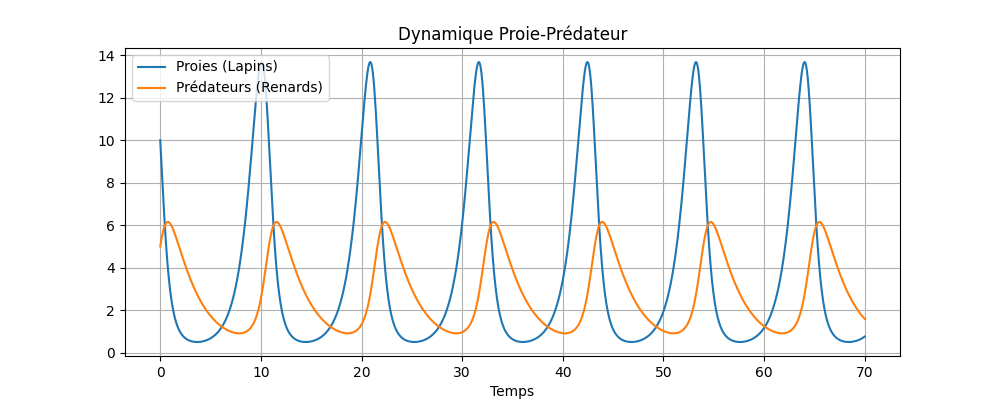

In [48]:
plt.figure(figsize=(10, 4))
plt.plot(t, y1, label='Proies (Lapins)')
plt.plot(t, y2, label='Prédateurs (Renards)')
plt.title("Dynamique Proie-Prédateur")
plt.xlabel("Temps")
plt.legend()
plt.grid(True)
plt.show()

## Exemple 3 : Le double pendule

Le passage des lois de la physique aux équations différentielles (ED) du double pendule est un défi, car les forces de tension dans les tiges rendent l'utilisation directe de $\vec{F} = m\vec{a}$ très laborieuse. On utilise donc le **Lagrangien**, qui repose sur l'énergie du système.

Voici les équations différentielles sous leur forme finale, prêtes à être intégrées.

#### Pour $\theta_1$ :
$$(m_1+m_2)L_1^2\ddot{\theta}_1 + m_2L_1L_2\ddot{\theta}_2\cos(\theta_1-\theta_2) + m_2L_1L_2\dot{\theta}_2^2\sin(\theta_1-\theta_2) + (m_1+m_2)gL_1\sin\theta_1 = 0$$

#### Pour $\theta_2$ :
$$m_2L_2^2\ddot{\theta}_2 + m_2L_1L_2\ddot{\theta}_1\cos(\theta_1-\theta_2) - m_2L_1L_2\dot{\theta}_1^2\sin(\theta_1-\theta_2) + m_2gL_2\sin\theta_2 = 0$$




### 1. Le Vecteur d'État
On définit le vecteur d'état $\mathbf{y}$ regroupant les angles $(\theta_1, \theta_2)$ et les vitesses angulaires $(\omega_1, \omega_2)$ :

$$\mathbf{y} = \begin{pmatrix} \theta_1 \\ \theta_2 \\ \omega_1 \\ \omega_2 \end{pmatrix}$$

### 2. Le Système d'Équations Différentielles
Le système $\mathbf{y}' = f(t, \mathbf{y})$ se décompose en quatre équations du premier ordre. Les deux premières sont triviales (la dérivée de l'angle est la vitesse) :

1. $\dot{\theta}_1 = \omega_1$
2. $\dot{\theta}_2 = \omega_2$

Les deux suivantes (les accélérations angulaires $\dot{\omega}_1$ et $\dot{\omega}_2$) sont beaucoup plus denses car elles sont **couplées** :



$$\dot{\omega}_1 = \frac{-g(2m_1 + m_2)\sin\theta_1 - m_2g\sin(\theta_1 - 2\theta_2) - 2\sin(\theta_1 - \theta_2)m_2(\omega_2^2 L_2 + \omega_1^2 L_1 \cos(\theta_1 - \theta_2))}{L_1(2m_1 + m_2 - m_2\cos(2\theta_1 - 2\theta_2))}$$

$$\dot{\omega}_2 = \frac{2\sin(\theta_1 - \theta_2)(\omega_1^2 L_1(m_1 + m_2) + g(m_1 + m_2)\cos\theta_1 + \omega_2^2 L_2 m_2 \cos(\theta_1 - \theta_2))}{L_2(2m_1 + m_2 - m_2\cos(2\theta_1 - 2\theta_2))}$$

---

### 3. Analyse des termes
* **Gravité ($g\sin\theta$) :** C'est la force de rappel classique du pendule simple.
* **Termes en $\sin(\theta_1 - \theta_2)$ :** Ils représentent le couplage. Si les deux pendules sont alignés, ce terme s'annule. Plus l'écart d'angle est grand, plus ils s'influencent mutuellement.
* **Termes en $\omega^2$ :** Ce sont les forces centrifuges liées à la rotation de chaque masse.
* **Le dénominateur :** Il contient un terme en $\cos(2\theta_1 - 2\theta_2)$. C'est ce qui rend l'équation **non-linéaire** et potentiellement chaotique : de petites variations de $\theta$ changent radicalement l'inertie effective du système.


## Exemple 4 : mouvement d'un satellite 

Considérons le mouvement d'un satellite orbitant dans le plan orbital de la Terre et du Soleil (supposés tous les deux fixes !). Le satellite est soumis à la force d'attraction de la Terre et à celle du Soleil. Ces forces s'écrivent :

$$
\overrightarrow{F_T}=-\frac{G m M_T}{r_T^2} \overrightarrow{e_T} \quad \overrightarrow{F_S}=-\frac{G m M_S}{r_T^2} \overrightarrow{e_S}
$$

et le principe fondamental de la mécanique donne:

$$
\overrightarrow{F_T}+\overrightarrow{F_S}=m \vec{a}
$$


Les données sont :
- $m$ : masse du satellite,
- $M_T$ : masse de la Terre,
- $M_S$ : masse du Soleil,
- $G$ : constante gravitationnelle,
- $r_T$ : distance du satellite à la Terre,
- $r_S$ : distance du satellite au Soleil,
- $\vec{e}_T$ : vecteur unitaire issu de la Terre dans la direction du satellite,
- $\vec{e}_S$ : vecteur unitaire issu du Soleil dans la direction du satellite.

Si $P(x(t), y(t))$ est la position du satellite, $S(x_S,y_S)$ la position du soleil et $T(x_T,y_T)$ la position de la terre, alors, le principe fondamental, projeté sur l'axe $x$, donne :
$$
\begin{pmatrix} x^{\prime \prime} (t) \\ y^{\prime \prime} (t) \end{pmatrix}
=\frac{G M_T}{||\overrightarrow{PT}||^3}\overrightarrow{PT}
   +\frac{G M_S}{||\overrightarrow{PS}||^3}\overrightarrow{PS}
$$
où en composante
$$
x^{\prime \prime}(t)=-\frac{G M_T\left(x(t)-x_T\right)}{\left(\left(x(t)-x_T\right)^2+\left(y(t)-y_T\right)^2\right)^{\frac{3}{2}}}-\frac{G M_S\left(x(t)-x_S\right)}{\left(\left(x(t)-x_S\right)^2+\left(y(t)-y_S\right)^2\right)^{\frac{3}{2}}}
$$

$$
y^{\prime \prime}(t)=-\frac{G M_T\left(y(t)-y_T\right)}{\left(\left(x(t)-x_T\right)^2+\left(y(t)-y_T\right)^2\right)^{\frac{3}{2}}}-\frac{G M_S\left(y(t)-y_S\right)}{\left(\left(x(t)-x_S\right)^2+\left(y(t)-y_S\right)^2\right)^{\frac{3}{2}}}
$$

On obtient une équation similaire pour $y^{\prime \prime}(t)$. On transforme ces deux équations d'ordre 2 en un système de 4 équations d'ordre 1



In [33]:
#CONSTANTES du SYSTEME : trouvé sur https://www.f-legrand.fr/scidoc/docmml/sciphys/meca/terre/terre.html
G_M_S = 0.0002959
G_M_T = 0.0000000008887

G_M_S = 0.0002959 * 10**5
G_M_T = 0.0000000008887 *10**5
T = np.array([-200,100]) # position de la terre
S = np.array([300,-100]) # position du soleil

def soleil_terre(t, y):
    P = np.array(y[:2]) #position 
    V = np.array(y[-2:]) #position 
    PT = T-P
    PS = S-P
    A = G_M_T / np.linalg.norm(PT)**3 * PT + G_M_S / np.linalg.norm(PS)**3 * PS
#    print(np.concatenate((V , A)))
    return np.concatenate((V , A))

In [64]:
# Paramètres de la solution

I = (0, 20000) # Intervalle de temps de la solution [t0, b]
y0 = np.array([-100, 0, 0.2, 0.1])  # Position initiale = (0;0), Vitesse initiale (1;1) en t_0

In [65]:
# Résolution avec  RK4 
t, y = rk4(soleil_terre, I[0],y0,I[1], 2000)
p_x, p_y, v_x, v_y= np.transpose(y) # les composantes du vecteur y



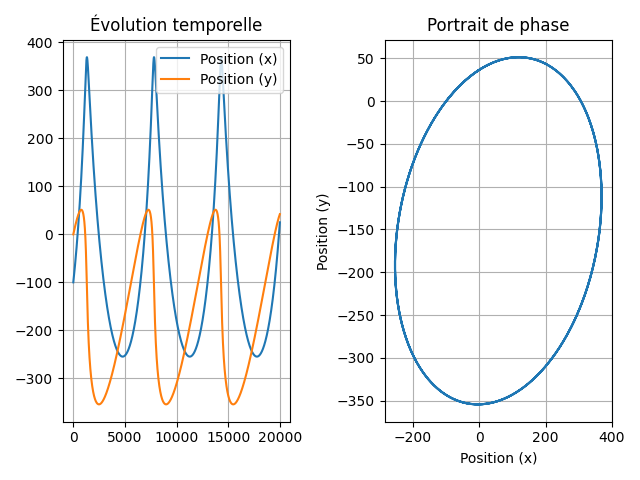

In [66]:
plt.figure()
plt.subplot(1, 2, 1)
plt.plot(t, p_x, label='Position (x)')
plt.plot(t, p_y, label='Position (y)')
plt.title("Évolution temporelle")
plt.legend()
plt.grid(True)

# Portrait de phase (Espace des états)
plt.subplot(1, 2, 2)
plt.plot(p_x, p_y)
plt.xlabel('Position (x)')
plt.ylabel('Position (y)')
plt.title("Portrait de phase")
plt.grid(True)

plt.tight_layout()
plt.show()

Considérons une équation différentielle d'ordre 2 , c'est-à-dire faisant intervenir $y(x), y^{\prime}(x)$ et $y^{\prime \prime}(x)$ :

$$
y^{\prime \prime}(x)=f\left(x, y, y^{\prime}\right) .
$$


Elle se transforme en un système de deux équations différentielles d'ordre 1 . On pose $z(x)=y^{\prime}(x)$ et on a alors :

$$
\left\{\begin{aligned}
y^{\prime}(x) & =z(x) \\
z^{\prime}(x) & =f(x, y, z)
\end{aligned}\right.
$$


La solution est généralement unique une fois que l'on a fixé les conditions initiales $y\left(x_0\right)$ et $y^{\prime}\left(x_0\right)$. On peut alors appliquer les méthodes numériques précédentes.

Le principe fondamental de la mécanique conduit naturellement à un système d'équations différentielles d'ordre 2 . En effet la vitesse est la dérivée de la position et l'accélération est la dérivée seconde de la position. Appliquons